In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def find_project_root(marker="requirements.txt"):
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker}")

PROJECT_ROOT = find_project_root()
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv(DATA_PROCESSED / "features_2022_2024.csv")
print(f"Loaded {len(df)} rows, {len(df.columns)} columns")
print(f"\nColumns: {list(df.columns)}")

Loaded 1359 rows, 20 columns

Columns: ['Year', 'Round', 'EventName', 'EventDate', 'Circuit', 'Abbreviation', 'FullName', 'TeamName', 'GridPosition', 'QualifyingPosition', 'Position', 'Points', 'Status', 'BestQualiTime', 'PoleTime', 'QualifyingGapToPole', 'DriverFormLast3', 'TeamFormLast3', 'DriverDNFRateLast5', 'IsStreetCircuit']


In [3]:
# Drop rows where rolling features couldn't be computed (early races)
modelable = df.dropna(subset=[
    "DriverFormLast3", "TeamFormLast3", "DriverDNFRateLast5",
    "QualifyingGapToPole", "GridPosition", "Position"
]).copy()

print(f"Rows with complete features: {len(modelable)} ({len(modelable)/len(df)*100:.1f}% of total)")
print(f"Drivers: {modelable['Abbreviation'].nunique()}")
print(f"Year breakdown: {dict(modelable['Year'].value_counts().sort_index())}")

Rows with complete features: 1296 (95.4% of total)
Drivers: 27
Year breakdown: {2022: np.int64(413), 2023: np.int64(432), 2024: np.int64(451)}


In [4]:
features = [
    "GridPosition",
    "QualifyingPosition",
    "QualifyingGapToPole",
    "DriverFormLast3",
    "TeamFormLast3",
    "DriverDNFRateLast5",
    "IsStreetCircuit",
]

correlations = modelable[features + ["Position"]].corr()["Position"].drop("Position")
correlations = correlations.sort_values(ascending=True)

print("Correlation with Position (lower position = better finish):\n")
for feat, val in correlations.items():
    print(f"  {feat:25s}: {val:+.3f}")

Correlation with Position (lower position = better finish):

  IsStreetCircuit          : +0.001
  DriverDNFRateLast5       : +0.048
  QualifyingGapToPole      : +0.367
  TeamFormLast3            : +0.517
  DriverFormLast3          : +0.553
  GridPosition             : +0.599
  QualifyingPosition       : +0.650


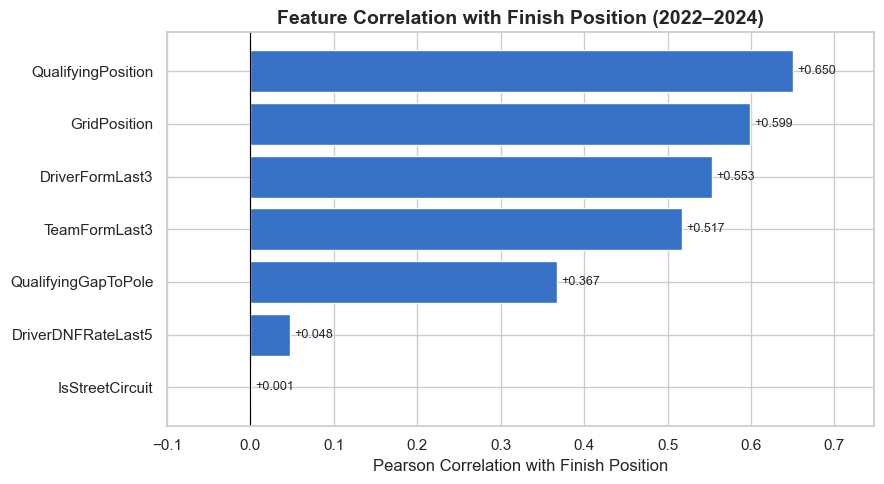

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#3671C6" if v > 0 else "#E10600" for v in correlations.values]
ax.barh(correlations.index, correlations.values, color=colors)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with Finish Position")
ax.set_title("Feature Correlation with Finish Position (2022–2024)",
             fontsize=14, fontweight="bold")
ax.bar_label(ax.containers[0], fmt="%+.3f", padding=3, fontsize=9)
ax.set_xlim(-0.1, max(correlations.values) * 1.15)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "chart_feature_correlations.png",
            dpi=120, bbox_inches="tight")
plt.show()

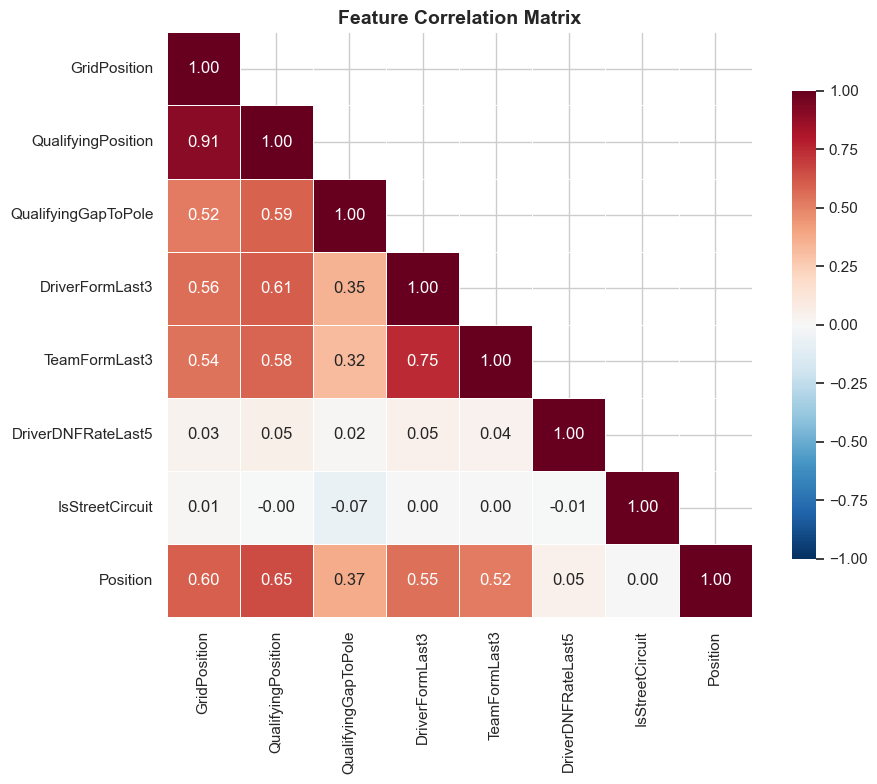

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = modelable[features + ["Position"]].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax
)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "chart_correlation_heatmap.png",
            dpi=120, bbox_inches="tight")
plt.show()

## Feature Engineering — Findings

The feature pipeline produces 7 candidate predictors, computed with proper temporal isolation
(rolling features use `.shift(1)` to prevent target leakage).

### Strongest individual predictors
- **QualifyingPosition (0.65)** and **GridPosition (0.60)** — qualifying performance dominates as expected
- **DriverFormLast3 (0.55)** and **TeamFormLast3 (0.52)** — recent form contributes meaningfully, with driver and team form roughly equal in predictive power

### Weaker than expected
- **QualifyingGapToPole (0.37)** — surprisingly weaker than QualifyingPosition. Gap is continuous and skewed; rank is ordinal. Linear correlation likely understates this feature's value for non-linear models.
- **DriverDNFRateLast5 (0.05)** — recent DNF history barely predicts finish position. DNFs may be too random (mechanical, incidents) to carry forward signal.
- **IsStreetCircuit (0.00)** — circuit type alone doesn't predict finish position. May still be useful in interaction with driver-specific features.

### Multicollinearity
- GridPosition and QualifyingPosition correlate at 0.91 — nearly redundant
- DriverFormLast3 and TeamFormLast3 correlate at 0.75 — overlap as expected

### Implications for modelling
- For a **linear baseline (logistic regression)**: regularisation needed to handle multicollinearity, or drop redundant features
- For **XGBoost**: the non-linear interactions between Gap, FormLast3, and circuit type are exactly where tree models add value over linear approaches
- DNF rate and street circuit flag may need replacement or dropping in feature selection